In [1]:
print("hi")

hi


In [4]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
load_dotenv()

llm=ChatOpenAI(model='gpt-5.5-2026-04-23')
llm.invoke("See, I worked on Terraform almost 2 years ago. Now, this organization is asking me to implement Terraform from scratch—literally from scratch. I've forgotten a few procedures now, so treat me like a fresher.\nI would like to use Azure DevOps for the pipeline, Terraform Cloud for the state file, and AWS as the provider. Please give me a complete roadmap . Note give me everything in text with markdown file special characters so that i can copy and view this content in .md file").content

'# Terraform From Scratch Roadmap\n\n## Goal\n\nYou want to implement Terraform from scratch using:\n\n| Component | Tool |\n|---|---|\n| CI/CD Pipeline | Azure DevOps |\n| Terraform State Storage | Terraform Cloud |\n| Cloud Provider | AWS |\n| IaC Tool | Terraform |\n\n---\n\n# 1. High-Level Architecture\n\n```text\nDeveloper\n   |\n   | Push Terraform code\n   v\nAzure Repos / GitHub Repo\n   |\n   | Trigger Pipeline\n   v\nAzure DevOps Pipeline\n   |\n   | terraform init / plan / apply\n   v\nTerraform Cloud\n   |\n   | Stores Terraform state remotely\n   v\nAWS\n   |\n   | Creates / Updates / Deletes infrastructure\n```\n\n---\n\n# 2. What You Need Before Starting\n\n## Accounts Required\n\nYou need access to:\n\n```text\n1. AWS Account\n2. Terraform Cloud Account\n3. Azure DevOps Organization\n4. Git Repository\n```\n\n---\n\n## Tools Required Locally\n\nInstall these on your laptop:\n\n```text\n1. Terraform CLI\n2. AWS CLI\n3. Git\n4. VS Code or any editor\n```\n\n---\n\n## Inst

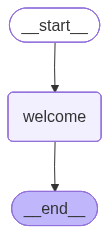

In [13]:
from typing import TypedDict
from langgraph.graph import StateGraph , START,END

class sample_schema(TypedDict):
    name:str
    message:str

def welcome(input:sample_schema)->sample_schema:
    name=input['name']
    message=input['message']
    response=llm.invoke(f"hi this is {name} , please explain about {message} .").content
    input['message']=response
    return input


graph=StateGraph(sample_schema)



graph.add_node("welcome",welcome)

graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

graph.compile()    




In [16]:

data={"name":"uthej","message":"I want you to create test cases for basic source file vs targe table ETL validation\n I want you to create in comma delimited with fields testcaseid , testcasedescription , expected results"}
graph.compile().invoke(data)

{'name': 'uthej',
 'message': 'Absolutely — below is a **comma-delimited test case list** for **basic source file vs target table ETL validation** with the fields:\n\n**testcaseid, testcasedescription, expected results**\n\n```csv\ntestcaseid,testcasedescription,expected results\nTC001,Validate source file record count matches target table record count,Source file record count should match target table record count\nTC002,Validate all source columns are loaded into the target table correctly,All mapped columns should match between source file and target table\nTC003,Validate data type conversion for numeric fields,Numeric values should be loaded correctly into target table without conversion errors\nTC004,Validate data type conversion for date fields,Date values should be loaded in the expected target format\nTC005,Validate blank or null values in source file are handled correctly,Blank or null values should be loaded according to ETL rules without errors\nTC006,Validate duplicate reco

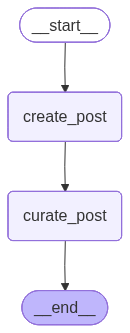

In [20]:
class post_schema(TypedDict):
    topic:str
    post:str
    curated_post:str


def create_post(state:post_schema)->post_schema:
    topic=state['topic']
    response=llm.invoke(f"please give in information about topic {topic}").content
    state['post']=response
    return state

def curate_post(state:post_schema)->post_schema:
    post=state['post']
    response=llm.invoke(f"please curate the below post for linkedin \n '{post}'").content
    state['curated_post']=response
    return state

post_graph=StateGraph(post_schema)
post_graph.add_node("create_post",create_post)
post_graph.add_node("curate_post",curate_post)

post_graph.add_edge(START,"create_post")
post_graph.add_edge("create_post","curate_post")
post_graph.add_edge("curate_post",END)

post_graph.compile()




In [21]:
first_graph=post_graph.compile()
first_graph.invoke({"topic":"sexual desires"})

{'topic': 'sexual desires',
 'post': 'Sexual desire is the feeling of wanting sexual activity or sexual intimacy. It’s a normal part of human life, and the level of desire can vary a lot from person to person and across different times in a person’s life.\n\n### Main things to know\n- **It’s influenced by many factors:** hormones, stress, sleep, mood, relationship quality, medications, health conditions, and past experiences.\n- **It changes over time:** desire may be stronger in some periods and lower in others.\n- **There’s no single “normal”:** some people feel sexual desire often, some rarely, and some not at all.\n- **It can be affected by emotions:** feeling safe, respected, and emotionally connected can increase desire for many people.\n\n### Common factors that affect sexual desire\n- **Physical health:** illness, pain, fatigue, hormonal changes\n- **Mental health:** anxiety, depression, stress, low self-esteem\n- **Medication:** some antidepressants and other drugs can lower d